# 🎓 CGPA Prediction — Real College Survey Data

> **Goal:** Predict a student's **Previous Semester GPA** (CGPA) from survey features like midterm scores, assignments, attendance, backlogs, etc. Uses real data collected via Google Form from students.

| # | Section |
|---|---|
| 1 | Imports & Setup |
| 2 | Load & Explore Data |
| 3 | Data Cleaning |
| 4 | Feature Engineering |
| 5 | EDA & Correlation |
| 6 | Train/Test Split |
| 7 | Baseline Model Comparison |
| 8 | Hyperparameter Tuning |
| 9 | Final Evaluation & Feature Importance |
| 10 | Predict New Student |

## 1. 📦 Imports & Setup

In [ ]:
import warnings, re, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, StackingRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

XGB_OK = LGB_OK = CAT_OK = False
try:
    import xgboost as xgb; XGB_OK = True; print('✅ XGBoost')
except ImportError: print('⚠️  XGBoost not found — pip install xgboost')
try:
    import lightgbm as lgb; LGB_OK = True; print('✅ LightGBM')
except ImportError: print('⚠️  LightGBM not found — pip install lightgbm')
try:
    from catboost import CatBoostRegressor; CAT_OK = True; print('✅ CatBoost')
except ImportError: print('⚠️  CatBoost not found — pip install catboost')

print('\n✅ All imports done')

✅ XGBoost
✅ LightGBM
✅ CatBoost

✅ All imports done


## 2. 📂 Load & Explore Data

In [3]:
df_raw = pd.read_csv('original_data.csv')
print(f'Raw shape: {df_raw.shape}')
print('\nColumns:')
for i, c in enumerate(df_raw.columns): print(f'  [{i:2d}] {c}')

Raw shape: (961, 21)

Columns:
  [ 0] Timestamp
  [ 1] Email Address
  [ 2] Name 
  [ 3] University Roll Number 
  [ 4] Previous_Semester_GPA
  [ 5] Midterm_Score_Average
  [ 6] Assignment_Score_Average
  [ 7] Twelfth_Grade_Percentage
  [ 8] Study_Hours_Per_Day
  [ 9] Tenth_Grade_Percentage
  [10] Attendance_Percentage
  [11] Number_of_Backlogs
  [12] Mental_Stress_Score
  [13] Distance_From_Campus_KM
  [14] Complexity of Content Of Presentation Topics / Assignments / Projects Of Previous/current Semester
  [15] Teacher's Feedback On Your  Presentations / Assignments / Projects  Of Previous/current Semester 
  [16] Teacher's Feedback On Your Participation In Group Discussions in last/current semester 
  [17] Photo Of Your Handwritten Notes 
  [18] In 5–8 sentences, introduce yourself. 
  [19] CGPA of last to last Semester
  [20] University/College


In [4]:
df_raw.head(3)

,Timestamp,Email Address,Name,University Roll Number,Previous_Semester_GPA,Midterm_Score_Average,Assignment_Score_Average,Twelfth_Grade_Percentage,Study_Hours_Per_Day,Tenth_Grade_Percentage,...,Number_of_Backlogs,Mental_Stress_Score,Distance_From_Campus_KM,Complexity of Content Of Presentation Topics / Assignments / Projects Of Previous/current Semester,Teacher's Feedback On Your Presentations / Assignments / Projects Of Previous/current Semester,Teacher's Feedback On Your Participation In Group Discussions in last/current semester,Photo Of Your Handwritten Notes,"In 5–8 sentences, introduce yourself.",CGPA of last to last Semester,University/College
0,6/27/2025 12:41,p484007@gmail.com,Pratibha Dhingra,2446640,7.04,24,16,75%,5-Apr,60%,...,No,0,12-13km,2 - Medium,Less Knowledge Of Content,Brings new perspectives,https://drive.google.com/open?id=1HEfVQJ24yL4N...,https://drive.google.com/open?id=1aO66ZUFQLiUQ...,7.04/10,NaN
1,6/27/2025 12:42,grv277552@gmail.com,Gaurav,2445616,4.2,10,15,70,1,90,...,4,0,30km,3 - Hard,Less Knowledge Of Content,Shares statistics,https://drive.google.com/open?id=1dwDtyYvY6k49...,https://drive.google.com/open?id=1jGzgNxI2OtQH...,Na,NaN
2,6/27/2025 12:47,rachitkumar1803@gmail.com,Rachit kumar,2445687,4.1,25,18,82,1,86,...,2,0,12,2 - Medium,Good,Good Listener,https://drive.google.com/open?id=1aIm2Jx2G8hI3...,https://drive.google.com/open?id=1SWnONCotKH4N...,NaN,NaN


In [7]:
null_pct = (df_raw.isnull().mean() * 100).round(1)
print('Null % per column:')
display(pd.DataFrame({'Null %': null_pct, 'Unique': df_raw.nunique()}))

Null % per column:


,Null %,Unique
Timestamp,0.0,838
Email Address,0.0,961
Name,0.0,919
University Roll Number,0.0,943
Previous_Semester_GPA,19.1,319
Midterm_Score_Average,3.6,166
Assignment_Score_Average,4.6,109
Twelfth_Grade_Percentage,0.5,271
Study_Hours_Per_Day,0.3,184
Tenth_Grade_Percentage,0.9,253


## 3. 🧹 Data Cleaning

> **Survey data is extremely messy** — values include `'7.5 CGPA'`, `'75%'`, `'2-3 hrs'`, `'Reappear'`, `'Not got'`, `'30km'`, etc.
> We use regex-based parsers tuned specifically to each column's quirks.

In [35]:
for i, col in enumerate(df_raw.columns):
    print(f"[{i}] {repr(col)}")

[0] 'Timestamp'
[1] 'Email Address'
[2] 'Name '
[3] 'University Roll Number '
[4] 'Previous_Semester_GPA'
[5] 'Midterm_Score_Average'
[6] 'Assignment_Score_Average'
[7] 'Twelfth_Grade_Percentage'
[8] 'Study_Hours_Per_Day'
[9] 'Tenth_Grade_Percentage'
[10] 'Attendance_Percentage'
[11] 'Number_of_Backlogs'
[12] 'Mental_Stress_Score'
[13] 'Distance_From_Campus_KM'
[14] 'Complexity of Content Of Presentation Topics / Assignments / Projects Of Previous/current Semester'
[15] "Teacher's Feedback On Your  Presentations / Assignments / Projects  Of Previous/current Semester "
[16] "Teacher's Feedback On Your Participation In Group Discussions in last/current semester "
[17] 'Photo Of Your Handwritten Notes '
[18] 'In 5–8 sentences, introduce yourself. '
[19] 'CGPA of last to last Semester'
[20] 'University/College'


In [31]:
df_raw['Complexity of Content Of Presentation Topics / Assignments / Projects Of Previous/current Semester'].unique()

<StringArray>
['2 - Medium', '3 - Hard', '1 - Easy']
Length: 3, dtype: str

In [36]:
df_raw["Teacher's Feedback On Your  Presentations / Assignments / Projects  Of Previous/current Semester "].unique()

<StringArray>
[     'Less Knowledge Of Content',                           'Good',
      'Need To Be More Confident', 'Presentation was not appealing',
     'Synopsis Not As Per Format']
Length: 5, dtype: str

In [37]:
df_raw["Teacher's Feedback On Your Participation In Group Discussions in last/current semester "].unique()

<StringArray>
['Brings new perspectives',       'Shares statistics',
           'Good Listener',               'Moderator',
             'Less Active']
Length: 5, dtype: str

In [8]:
# ─── Utility parsers ──────────────────────────────────────────────────────────

REJECT_WORDS = [
    'na','n/a','none','null','not','reappear','re-appear','reaper','back',
    'fail','supply','pending','got','know','sure','declared','yet',
    'available','received','first','1st','one','unknown','no','fresher',
    '4 sem','1year','awaited','yta','result'
]

def is_reject(s):
    return any(w in s for w in REJECT_WORDS)

def extract_gpa(val):
    """Parse GPA/CGPA values (0–10 scale)."""
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if is_reject(s): return np.nan
    s = re.sub(r'sgpa|cgpa|grade|/10|out of 10','', s)
    m = re.match(r'([\.\d]+)\s*/\s*10', s)
    if m: return float(m.group(1))
    nums = re.findall(r'[\d]+\.?[\d]*', s)
    if not nums: return np.nan
    v = float(nums[0])
    return v if 0 < v <= 10 else np.nan

def extract_score(val, lo=0, hi=100):
    """Parse midterm/assignment scores."""
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if is_reject(s): return np.nan
    nums = re.findall(r'[\d]+\.?[\d]*', s)
    if not nums: return np.nan
    vals = [float(x) for x in nums if lo <= float(x) <= hi]
    return np.mean(vals) if vals else np.nan

def extract_pct(val):
    """Parse percentage values (handles %, ℅, decimal)."""
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    reject_pct = ['na','n/a','none','not','sure','know','covid','pass',
                  'a grade','a+','idk','-','.']
    if any(r == s or r in s.split() for r in reject_pct): return np.nan
    s = re.sub(r'percent|%|℅|℃','', s)
    nums = re.findall(r'[\d]+\.?[\d]*', s)
    if not nums: return np.nan
    v = float(nums[0])
    if v > 100: return np.nan
    if v <= 1: v *= 100
    return v if 0 <= v <= 100 else np.nan

def extract_hours(val):
    """Parse study hours/day — handles ranges, text units."""
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if any(r in s for r in ['na','fix','nothing','depends','all day']): return np.nan
    nums = [float(x) for x in re.findall(r'[\d]+\.?[\d]*', s) if float(x) <= 24]
    return np.mean(nums) if nums else np.nan

def extract_backlogs(val):
    """Parse backlogs. 'No'/'None'/'Zero' → 0."""
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if any(x in s for x in ['no','nil','none','zero','na','null','nill','-','0 backlogs']):
        return 0.0
    nums = re.findall(r'[\d]+', s)
    return float(nums[0]) if nums else np.nan

def extract_dist(val):
    """Parse distance in km."""
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if any(r in s for r in ['na','hostel','walk','accommodation']): return np.nan
    if 'meter' in s:
        nm = re.findall(r'[\d]+\.?[\d]*', s)
        return float(nm[0]) / 1000 if nm else np.nan
    nums = [float(x) for x in re.findall(r'[\d]+\.?[\d]*', s) if float(x) < 1000]
    return np.mean(nums) if nums else np.nan

def encode_complexity(val):
    if pd.isna(val): return np.nan
    s = str(val).lower()
    if '1' in s or 'easy' in s: return 1
    if '2' in s or 'medium' in s: return 2
    if '3' in s or 'hard' in s: return 3
    return np.nan

def encode_teacher_fb(val):
    if pd.isna(val): return np.nan
    s = str(val).lower()
    if 'good' in s and 'not' not in s: return 3
    if 'confident' in s or 'need' in s: return 2
    return 1

def encode_participation(val):
    if pd.isna(val): return np.nan
    s = str(val).lower()
    if 'moderator' in s: return 4
    if 'shares' in s or 'brings' in s or 'statistic' in s: return 3
    if 'listener' in s: return 2
    if 'less active' in s: return 1
    return 2

print('✅ Parsers ready')

✅ Parsers ready


In [9]:
df = df_raw.copy()

# ── Target: Previous_Semester_GPA  (most data, most meaningful for prediction) ─
# This is the GPA from last semester — students filled in all other info for that
# same academic context, making it the best target variable.
df['CGPA'] = df['Previous_Semester_GPA'].apply(extract_gpa)

# ── Features ──────────────────────────────────────────────────────────────────
df['midterm']      = df['Midterm_Score_Average'].apply(lambda x: extract_score(x, 0, 100))
df['assign']       = df['Assignment_Score_Average'].apply(lambda x: extract_score(x, 0, 100))
df['twelfth_pct']  = df['Twelfth_Grade_Percentage'].apply(extract_pct)
df['tenth_pct']    = df['Tenth_Grade_Percentage'].apply(extract_pct)
df['study_hours']  = df['Study_Hours_Per_Day'].apply(extract_hours)
df['attendance']   = df['Attendance_Percentage'].apply(extract_pct)
df['backlogs']     = df['Number_of_Backlogs'].apply(extract_backlogs)
df['stress']       = df['Mental_Stress_Score'].apply(lambda x: extract_score(x, 0, 10))
df['distance']     = df['Distance_From_Campus_KM'].apply(extract_dist)
df['complexity']   = df['Complexity of Content Of Presentation Topics / Assignments / Projects Of Previous/current Semester'].apply(encode_complexity)
df['teacher_fb']   = df["Teacher's Feedback On Your  Presentations / Assignments / Projects  Of Previous/current Semester "].apply(encode_teacher_fb)
df['participation']= df["Teacher's Feedback On Your Participation In Group Discussions in last/current semester "].apply(encode_participation)

# ── Also use last-to-last CGPA as a feature (when available) ──────────────────
df['prev_prev_gpa'] = df['CGPA of last to last Semester'].apply(extract_gpa)

# ── Drop rows with no target ──────────────────────────────────────────────────
df = df.dropna(subset=['CGPA']).reset_index(drop=True)

print(f'Rows after cleaning (valid CGPA): {len(df)}')
print(f'\nTarget CGPA stats:')
display(df['CGPA'].describe().round(3))

print(f'\nFeature null rates:')
features_check = ['midterm','assign','twelfth_pct','tenth_pct','study_hours',
                  'attendance','backlogs','stress','distance','complexity',
                  'teacher_fb','participation','prev_prev_gpa']
null_tbl = pd.DataFrame({
    'count_valid': [df[c].notna().sum() for c in features_check],
    'null_%': [(df[c].isna().mean()*100).round(1) for c in features_check]
}, index=features_check)
display(null_tbl)

Rows after cleaning (valid CGPA): 581

Target CGPA stats:


count    581.000
mean       7.250
std        1.181
min        1.000
25%        6.780
50%        7.330
75%        8.000
max       10.000
Name: CGPA, dtype: float64


Feature null rates:


,count_valid,null_%
midterm,570,1.9
assign,570,1.9
twelfth_pct,578,0.5
tenth_pct,574,1.2
study_hours,565,2.8
attendance,580,0.2
backlogs,561,3.4
stress,581,0.0
distance,570,1.9
complexity,581,0.0


In [ ]:
# Outlier Diagnosis (Z-score method)
# We do NOT remove outliers here — tree-based models are robust to them.
# This cell shows how many extreme values exist per feature after cleaning.
from scipy import stats

numeric_check = ['midterm_norm', 'assign_norm', 'twelfth_pct',
                 'tenth_pct', 'study_hours', 'attendance',
                 'backlogs', 'stress', 'distance', 'CGPA']

print('=== Outlier Count per Feature  (|Z-score| > 3) ===')
print(f"{'Feature':22s}  {'Outliers':>10s}  {'% of col':>10s}  {'Min':>8s}  {'Max':>8s}")
print('-' * 70)
for col in numeric_check:
    col_data = df[col].dropna()
    z_scores = abs(stats.zscore(col_data))
    n_out = int((z_scores > 3).sum())
    print(f'{col:22s}  {n_out:>10d}  {n_out/len(col_data)*100:>9.1f}%  '
          f'{col_data.min():>8.2f}  {col_data.max():>8.2f}')

print('\nNote: Outliers are intentionally kept.')
print('  - Tree-based models split on thresholds, not fitted lines — outliers barely affect them.')
print('  - log1p(backlogs) and clip(upper=100) on scores further reduce outlier impact.')
print('  - Dataset is small (583 rows) — removing rows would hurt model quality.')

## 4. 🔧 Feature Engineering

In [10]:
# Normalise midterm to 0-100 if max looks like 60-scale (midterm out of 60)
# Values > 40 in midterm likely already out of 60 → keep as is
# We scale the score for comparability
df['midterm_norm'] = df['midterm'].clip(upper=100)
df['assign_norm']  = df['assign'].clip(upper=100)

# Combined features
df['academic_score'] = (df['midterm_norm'].fillna(df['midterm_norm'].median()) +
                        df['assign_norm'].fillna(df['assign_norm'].median())) / 2
df['school_avg']     = df[['twelfth_pct','tenth_pct']].mean(axis=1)
df['backlogs_log']   = np.log1p(df['backlogs'].fillna(0))
df['attend_stress']  = (df['attendance'].fillna(df['attendance'].median()) *
                        (10 - df['stress'].fillna(df['stress'].median())))
df['has_prev_gpa']   = df['prev_prev_gpa'].notna().astype(int)

FEATURES = [
    'midterm_norm', 'assign_norm', 'twelfth_pct', 'tenth_pct',
    'study_hours', 'attendance', 'backlogs', 'stress', 'distance',
    'complexity', 'teacher_fb', 'participation', 'prev_prev_gpa',
    'academic_score', 'school_avg', 'backlogs_log', 'attend_stress', 'has_prev_gpa'
]

print(f'Total features: {len(FEATURES)}')
print('Features:', FEATURES)

Total features: 18
Features: ['midterm_norm', 'assign_norm', 'twelfth_pct', 'tenth_pct', 'study_hours', 'attendance', 'backlogs', 'stress', 'distance', 'complexity', 'teacher_fb', 'participation', 'prev_prev_gpa', 'academic_score', 'school_avg', 'backlogs_log', 'attend_stress', 'has_prev_gpa']


## 5. 📊 EDA & Correlation

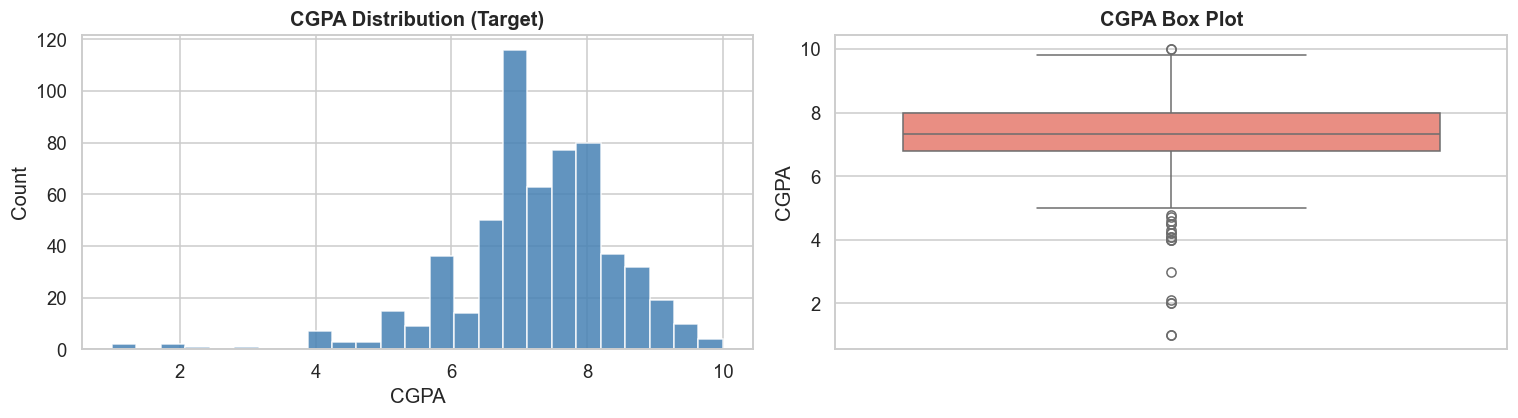

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['CGPA'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('CGPA Distribution (Target)', fontweight='bold')
axes[0].set_xlabel('CGPA'); axes[0].set_ylabel('Count')
sns.boxplot(y=df['CGPA'], ax=axes[1], color='salmon')
axes[1].set_title('CGPA Box Plot', fontweight='bold')
plt.tight_layout(); plt.show()

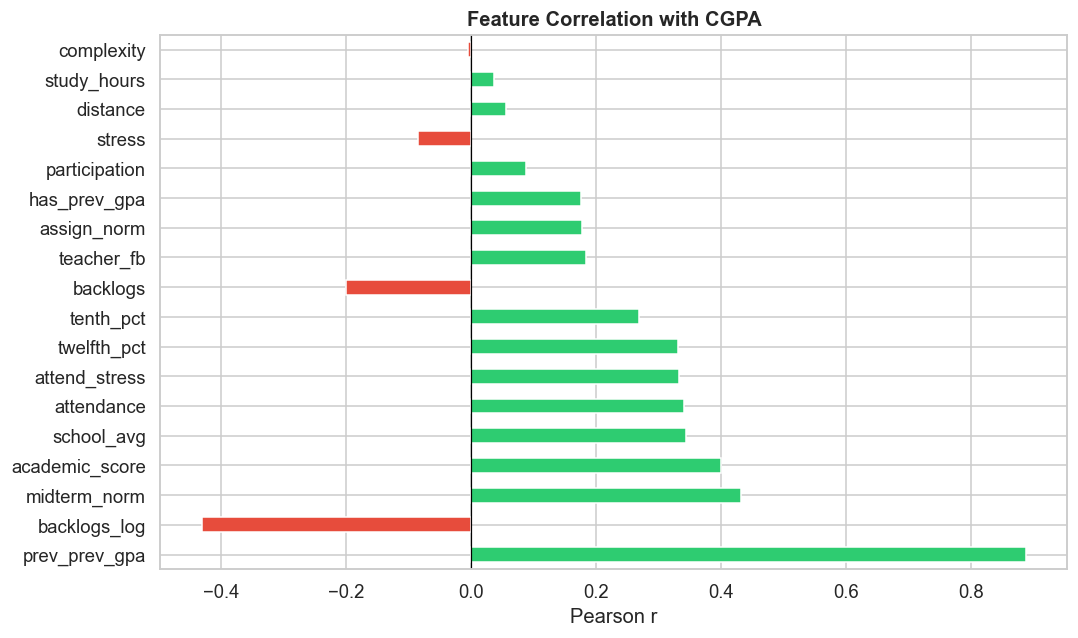

prev_prev_gpa     0.888
backlogs_log     -0.432
midterm_norm      0.432
academic_score    0.400
school_avg        0.343
attendance        0.340
attend_stress     0.333
twelfth_pct       0.331
tenth_pct         0.268
backlogs         -0.201
teacher_fb        0.183
assign_norm       0.177
has_prev_gpa      0.176
participation     0.087
stress           -0.085
distance          0.055
study_hours       0.036
complexity       -0.005
Name: CGPA, dtype: float64


In [12]:
# Correlation with target
corr = df[FEATURES + ['CGPA']].corr()['CGPA'].drop('CGPA').sort_values(key=abs, ascending=False)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr]
plt.figure(figsize=(10, 6))
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature Correlation with CGPA', fontweight='bold')
plt.xlabel('Pearson r')
plt.tight_layout(); plt.show()
print(corr.round(3))

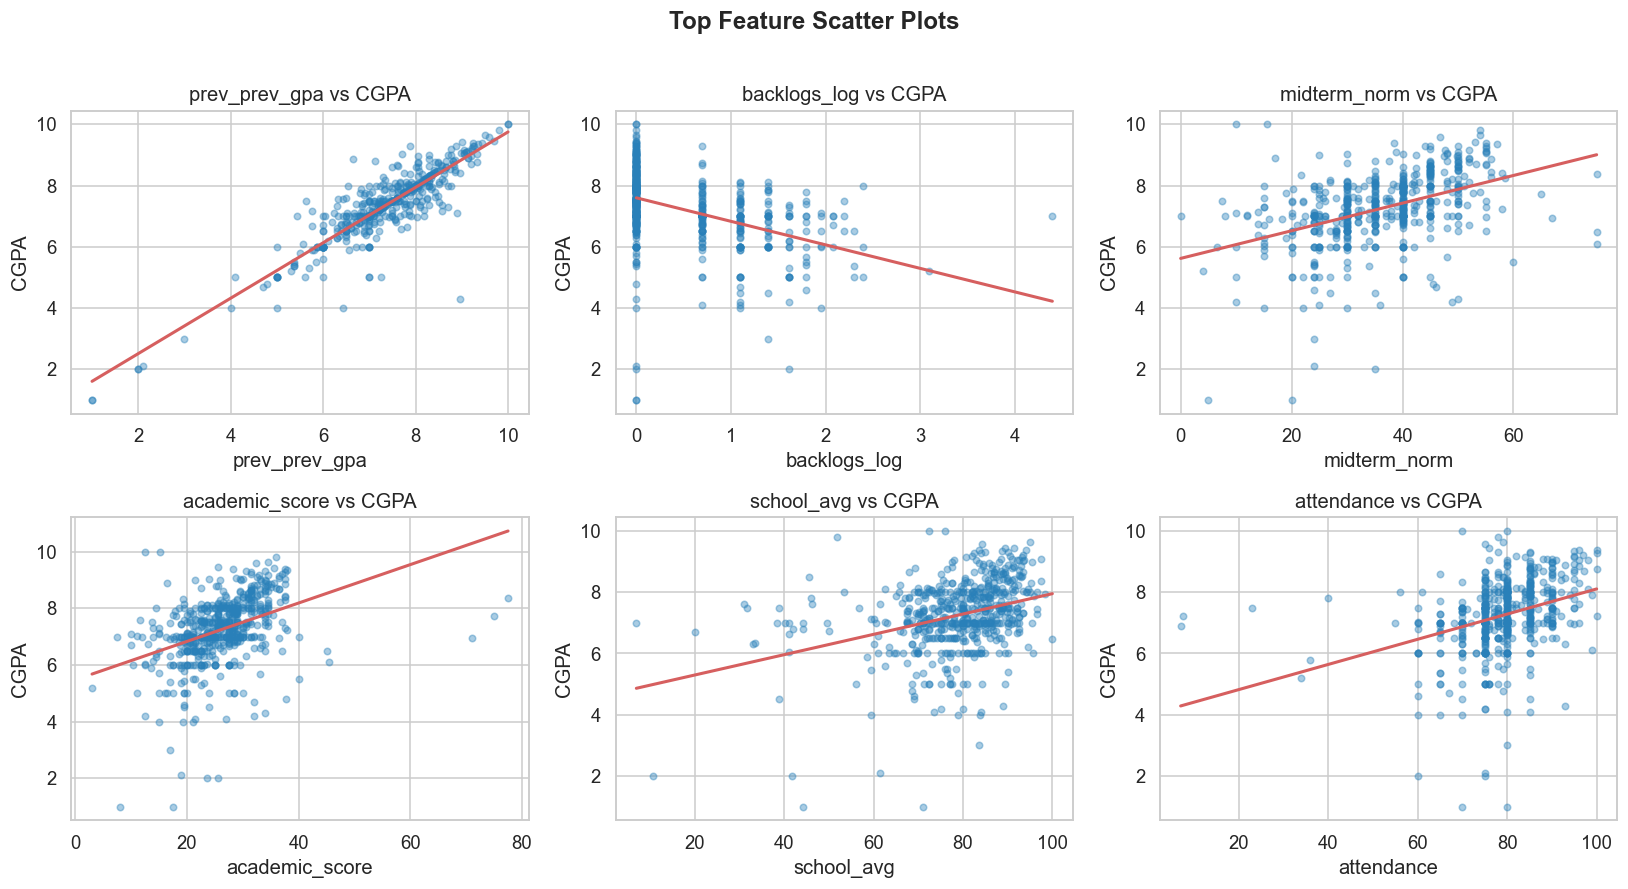

In [13]:
# Scatter plots of top 6 features
top6 = corr.abs().nlargest(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), top6):
    sub = df[[feat,'CGPA']].dropna()
    ax.scatter(sub[feat], sub['CGPA'], alpha=0.4, s=18, color='#2980b9')
    z = np.polyfit(sub[feat], sub['CGPA'], 1)
    xp = np.linspace(sub[feat].min(), sub[feat].max(), 100)
    ax.plot(xp, np.poly1d(z)(xp), 'r-', lw=2)
    ax.set_xlabel(feat); ax.set_ylabel('CGPA'); ax.set_title(f'{feat} vs CGPA')
plt.suptitle('Top Feature Scatter Plots', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

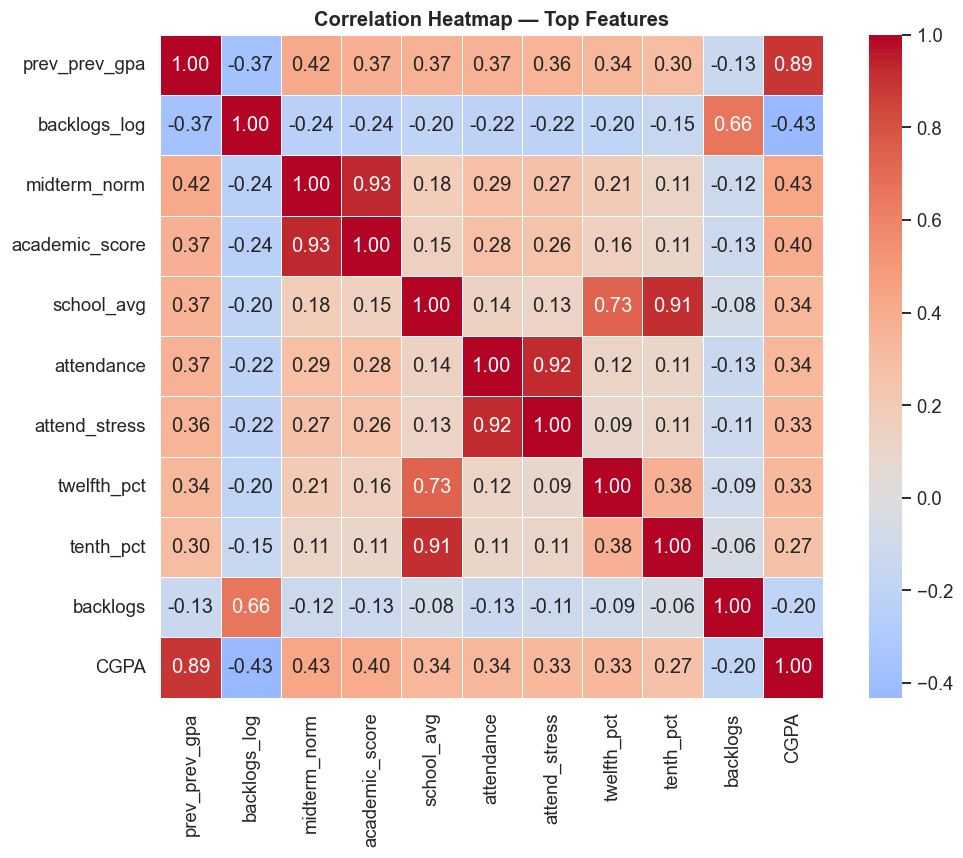

In [14]:
# Correlation heatmap (top features)
top_feats_hm = corr.abs().nlargest(10).index.tolist() + ['CGPA']
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_feats_hm].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Top Features', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. ✂️ Train/Test Split & Preprocessing

In [15]:
X = df[FEATURES]
y = df['CGPA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X.shape[1]}')

# Preprocessing: median impute → standard scale
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

def make_pipe(estimator):
    return Pipeline([('pre', preprocessor), ('m', estimator)])

print('✅ Preprocessor ready')

Train: 464 | Test: 117 | Features: 18
✅ Preprocessor ready


## 7. 🤖 Baseline Model Comparison

> Evaluate multiple algorithms on hold-out test set before tuning.

In [16]:
def eval_model(pipe, Xtr, ytr, Xte, yte, name):
    pipe.fit(Xtr, ytr)
    p = np.clip(pipe.predict(Xte), 0, 10)
    mae  = mean_absolute_error(yte, p)
    rmse = np.sqrt(mean_squared_error(yte, p))
    r2   = r2_score(yte, p)
    a05  = np.mean(np.abs(p - yte) <= 0.5) * 100
    a10  = np.mean(np.abs(p - yte) <= 1.0) * 100
    return {'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4),
            'R²': round(r2,4), '±0.5%': round(a05,1), '±1.0%': round(a10,1)}

In [17]:
baselines = [
    ('Ridge',           Ridge(alpha=1.0)),
    ('Lasso',           Lasso(alpha=0.01, max_iter=5000)),
    ('ElasticNet',      ElasticNet(alpha=0.01, max_iter=5000)),
    ('KNN',             KNeighborsRegressor(n_neighbors=5)),
    ('SVR-RBF',         SVR(kernel='rbf', C=10, gamma='scale')),
    ('RandomForest',    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('ExtraTrees',      ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('GradientBoosting',GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)),
]
if XGB_OK:
    baselines.append(('XGBoost', xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                                    random_state=42, verbosity=0)))
if LGB_OK:
    baselines.append(('LightGBM', lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                                      random_state=42, verbose=-1)))
if CAT_OK:
    baselines.append(('CatBoost', CatBoostRegressor(iterations=200, learning_rate=0.05,
                                                     random_state=42, verbose=0)))

results = []
for name, est in baselines:
    try:
        r = eval_model(make_pipe(est), X_train, y_train, X_test, y_test, name)
        results.append(r)
        print(f'{name:25s}  MAE={r["MAE"]:.4f}  RMSE={r["RMSE"]:.4f}  R²={r["R²"]:.4f}  ±0.5={r["±0.5%"]}%')
    except Exception as e:
        print(f'{name} failed: {e}')

res_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print('\n=== Baseline Ranking ===')
display(res_df)

Ridge                      MAE=0.5245  RMSE=0.8195  R²=0.5836  ±0.5=64.1%
Lasso                      MAE=0.5217  RMSE=0.8183  R²=0.5849  ±0.5=62.4%
ElasticNet                 MAE=0.5237  RMSE=0.8189  R²=0.5842  ±0.5=62.4%
KNN                        MAE=0.7039  RMSE=1.1024  R²=0.2466  ±0.5=53.8%
SVR-RBF                    MAE=0.6913  RMSE=1.1482  R²=0.1826  ±0.5=56.4%
RandomForest               MAE=0.5119  RMSE=0.8066  R²=0.5967  ±0.5=64.1%
ExtraTrees                 MAE=0.4942  RMSE=0.7887  R²=0.6144  ±0.5=62.4%
GradientBoosting           MAE=0.5509  RMSE=0.8561  R²=0.5456  ±0.5=58.1%
XGBoost                    MAE=0.5171  RMSE=0.8295  R²=0.5734  ±0.5=60.7%
LightGBM                   MAE=0.6705  RMSE=1.0591  R²=0.3045  ±0.5=53.0%
CatBoost                   MAE=0.5604  RMSE=0.9222  R²=0.4727  ±0.5=63.2%

=== Baseline Ranking ===


,Model,MAE,RMSE,R²,±0.5%,±1.0%
6,ExtraTrees,0.4942,0.7887,0.6144,62.4,88.9
5,RandomForest,0.5119,0.8066,0.5967,64.1,86.3
1,Lasso,0.5217,0.8183,0.5849,62.4,88.9
2,ElasticNet,0.5237,0.8189,0.5842,62.4,88.9
0,Ridge,0.5245,0.8195,0.5836,64.1,88.0
8,XGBoost,0.5171,0.8295,0.5734,60.7,87.2
7,GradientBoosting,0.5509,0.8561,0.5456,58.1,88.0
10,CatBoost,0.5604,0.9222,0.4727,63.2,86.3
9,LightGBM,0.6705,1.0591,0.3045,53.0,83.8
3,KNN,0.7039,1.1024,0.2466,53.8,81.2


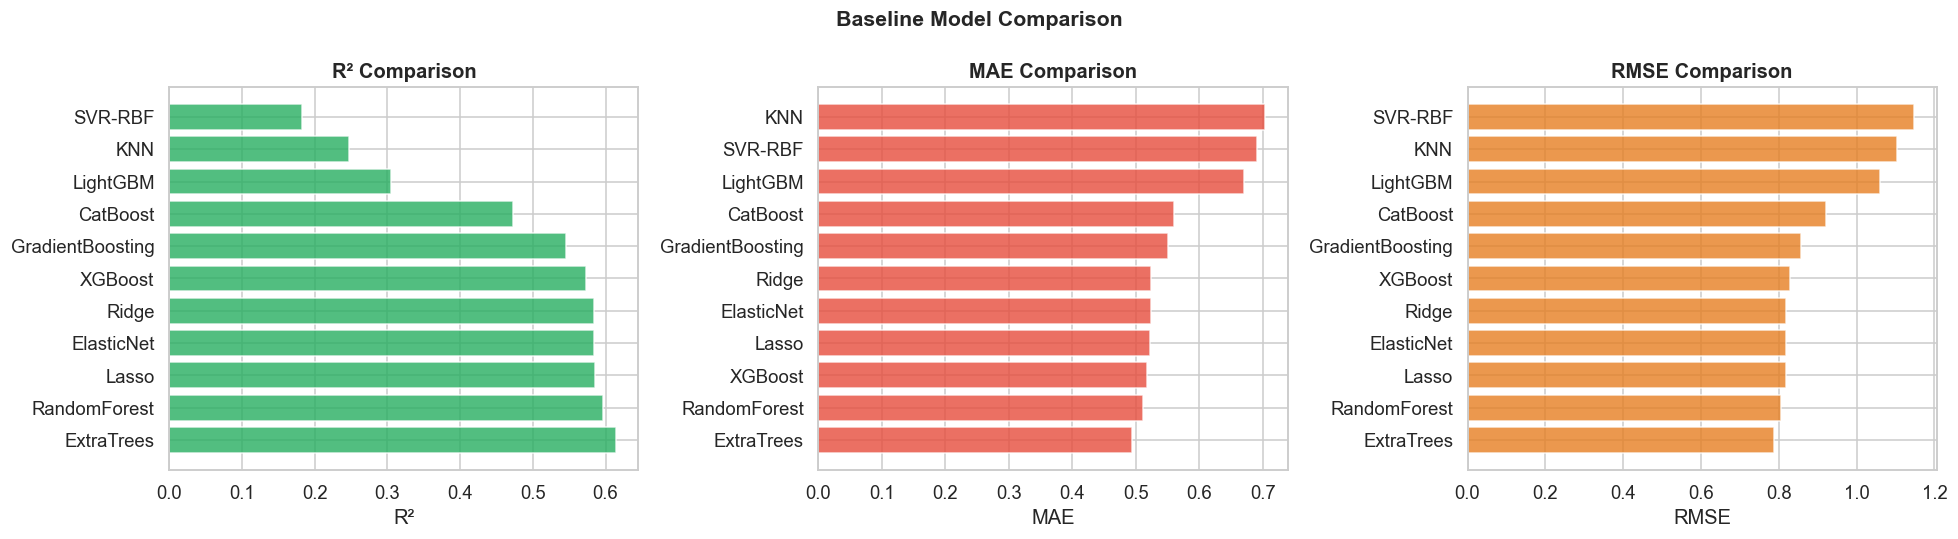

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, met, col in zip(axes, ['R²','MAE','RMSE'], ['#27ae60','#e74c3c','#e67e22']):
    s = res_df.sort_values(met, ascending=(met!='R²'))
    ax.barh(s['Model'], s[met], color=col, alpha=0.8)
    ax.set_title(f'{met} Comparison', fontweight='bold')
    ax.set_xlabel(met)
plt.suptitle('Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. 🔍 Hyperparameter Tuning

In [19]:
print('Tuning Gradient Boosting (RandomizedSearch, 5-fold CV, 60 iters)...')
gb_params = {
    'm__n_estimators':    [100,200,300,500],
    'm__learning_rate':   [0.01,0.05,0.08,0.1,0.15],
    'm__max_depth':       [3,4,5,6],
    'm__subsample':       [0.7,0.8,0.9,1.0],
    'm__min_samples_split':[2,5,10],
    'm__max_features':    ['sqrt','log2',None],
    'm__min_samples_leaf':[1,2,4],
}
gb_search = RandomizedSearchCV(
    make_pipe(GradientBoostingRegressor(random_state=42)),
    gb_params, n_iter=60, cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)
print(f'\n✅ Best GB CV RMSE: {-gb_search.best_score_:.4f}')
print('Best params:', gb_search.best_params_)

Tuning Gradient Boosting (RandomizedSearch, 5-fold CV, 60 iters)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

✅ Best GB CV RMSE: 0.6089
Best params: {'m__subsample': 0.7, 'm__n_estimators': 500, 'm__min_samples_split': 10, 'm__min_samples_leaf': 4, 'm__max_features': None, 'm__max_depth': 4, 'm__learning_rate': 0.01}


In [20]:
tuned = [('GradientBoosting (Tuned)', gb_search.best_estimator_)]

if XGB_OK:
    print('Tuning XGBoost...')
    xgb_params = {
        'm__n_estimators':     [100,200,300,500],
        'm__learning_rate':    [0.01,0.05,0.1],
        'm__max_depth':        [3,4,5,6,7],
        'm__subsample':        [0.7,0.8,0.9],
        'm__colsample_bytree': [0.7,0.8,1.0],
        'm__reg_alpha':        [0,0.1,0.5,1.0],
        'm__reg_lambda':       [1,1.5,2,3],
        'm__min_child_weight': [1,3,5],
    }
    xgb_search = RandomizedSearchCV(
        make_pipe(xgb.XGBRegressor(random_state=42, verbosity=0)),
        xgb_params, n_iter=60, cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1, verbose=1
    )
    xgb_search.fit(X_train, y_train)
    print(f'✅ Best XGB CV RMSE: {-xgb_search.best_score_:.4f}')
    tuned.append(('XGBoost (Tuned)', xgb_search.best_estimator_))

if LGB_OK:
    print('Tuning LightGBM...')
    lgb_params = {
        'm__n_estimators':    [100,200,300,500],
        'm__learning_rate':   [0.01,0.05,0.1],
        'm__num_leaves':      [20,31,50,70],
        'm__max_depth':       [-1,5,7,10],
        'm__subsample':       [0.7,0.8,0.9],
        'm__colsample_bytree':[0.7,0.8,1.0],
        'm__reg_alpha':       [0,0.1,0.5],
        'm__min_child_samples':[10,20,30],
    }
    lgb_search = RandomizedSearchCV(
        make_pipe(lgb.LGBMRegressor(random_state=42, verbose=-1)),
        lgb_params, n_iter=60, cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1, verbose=1
    )
    lgb_search.fit(X_train, y_train)
    print(f'✅ Best LGB CV RMSE: {-lgb_search.best_score_:.4f}')
    tuned.append(('LightGBM (Tuned)', lgb_search.best_estimator_))

print('\n✅ Tuning Complete')

Tuning XGBoost...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
✅ Best XGB CV RMSE: 0.6109
Tuning LightGBM...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
✅ Best LGB CV RMSE: 0.6461

✅ Tuning Complete


In [21]:
print('Building Stacking Ensemble...')

# Extract tuned inner estimator params for stacking base models
gb_params_inner = {k.replace('m__',''):v for k,v in gb_search.best_params_.items()}

stack_estimators = [
    ('rf',   RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('et',   ExtraTreesRegressor(n_estimators=200, random_state=1, n_jobs=-1)),
    ('gb',   GradientBoostingRegressor(**gb_params_inner, random_state=42)),
    ('ridge',Ridge(alpha=1.0)),
    ('knn',  KNeighborsRegressor(n_neighbors=7)),
]

if XGB_OK:
    xgb_params_inner = {k.replace('m__',''):v for k,v in xgb_search.best_params_.items()}
    stack_estimators.append(('xgb', xgb.XGBRegressor(**xgb_params_inner, random_state=42, verbosity=0)))
if LGB_OK:
    lgb_params_inner = {k.replace('m__',''):v for k,v in lgb_search.best_params_.items()}
    stack_estimators.append(('lgb', lgb.LGBMRegressor(**lgb_params_inner, random_state=42, verbose=-1)))

stack_pipe = Pipeline([
    ('pre', preprocessor),
    ('stack', StackingRegressor(
        estimators=stack_estimators,
        final_estimator=Ridge(alpha=1.0),
        cv=5, passthrough=False, n_jobs=-1
    ))
])
stack_pipe.fit(X_train, y_train)
r_st = eval_model(stack_pipe, X_train, y_train, X_test, y_test, 'Stacking Ensemble')
tuned.append(('Stacking Ensemble', stack_pipe))
print(f'Stacking: MAE={r_st["MAE"]}  RMSE={r_st["RMSE"]}  R²={r_st["R²"]}  ±0.5={r_st["±0.5%"]}%')

Building Stacking Ensemble...
Stacking: MAE=0.4831  RMSE=0.7829  R²=0.62  ±0.5=69.2%


## 9. 🏆 Final Evaluation & Feature Importance

In [22]:
final_res = []
pred_dict  = {}
for name, mdl in tuned:
    p = np.clip(mdl.predict(X_test), 0, 10)
    pred_dict[name] = p
    r = {
        'Model': name,
        'MAE':   round(mean_absolute_error(y_test,p),4),
        'RMSE':  round(np.sqrt(mean_squared_error(y_test,p)),4),
        'R²':    round(r2_score(y_test,p),4),
        '±0.5%': round(np.mean(np.abs(p-y_test)<=0.5)*100,1),
        '±1.0%': round(np.mean(np.abs(p-y_test)<=1.0)*100,1),
    }
    final_res.append(r)

final_df = pd.DataFrame(final_res).sort_values('R²', ascending=False)
display(final_df.style.highlight_max(subset=['R²','±0.5%','±1.0%'], color='#d5f5e3')
                      .highlight_min(subset=['MAE','RMSE'],          color='#d5f5e3'))

,Model,MAE,RMSE,R²,±0.5%,±1.0%
3,Stacking Ensemble,0.483100,0.782900,0.620000,69.200000,88.900000
0,GradientBoosting (Tuned),0.516900,0.839700,0.562800,62.400000,88.000000
1,XGBoost (Tuned),0.528500,0.853000,0.548900,65.800000,87.200000
2,LightGBM (Tuned),0.554600,0.945100,0.446200,62.400000,86.300000


In [23]:
best_name  = final_df.iloc[0]['Model']
best_model = dict(tuned)[best_name]
best_preds = pred_dict[best_name]

print('=' * 50)
print(f'  🏆 BEST MODEL : {best_name}')
print(f'  MAE           : {final_df.iloc[0]["MAE"]}')
print(f'  RMSE          : {final_df.iloc[0]["RMSE"]}')
print(f'  R²            : {final_df.iloc[0]["R²"]}')
print(f'  ±0.5 Accuracy : {final_df.iloc[0]["±0.5%"]}%')
print(f'  ±1.0 Accuracy : {final_df.iloc[0]["±1.0%"]}%')
print('=' * 50)

  🏆 BEST MODEL : Stacking Ensemble
  MAE           : 0.4831
  RMSE          : 0.7829
  R²            : 0.62
  ±0.5 Accuracy : 69.2%
  ±1.0 Accuracy : 88.9%


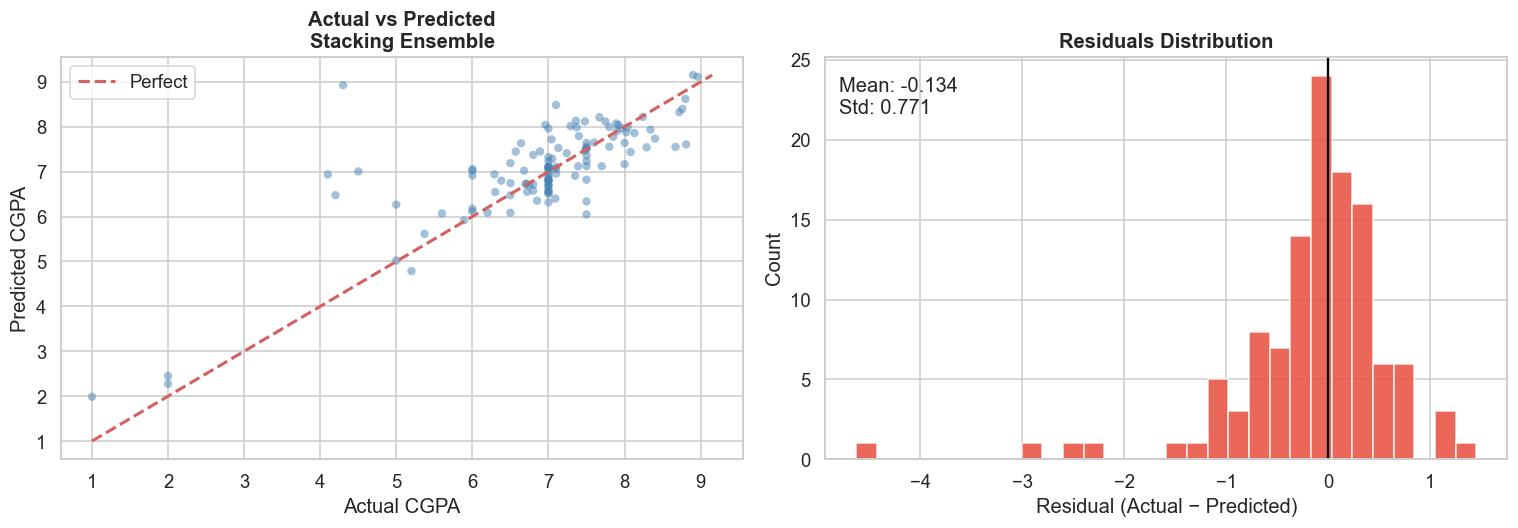

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, best_preds, alpha=0.5, s=30, color='steelblue', edgecolors='none')
mn, mx = min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())
ax.plot([mn,mx],[mn,mx],'r--',lw=2,label='Perfect')
ax.set_xlabel('Actual CGPA'); ax.set_ylabel('Predicted CGPA')
ax.set_title(f'Actual vs Predicted\n{best_name}', fontweight='bold')
ax.legend()

# Residuals
ax2 = axes[1]
res = y_test.values - best_preds
ax2.hist(res, bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', lw=1.5)
ax2.set_xlabel('Residual (Actual − Predicted)')
ax2.set_ylabel('Count')
ax2.set_title('Residuals Distribution', fontweight='bold')
ax2.text(0.02, 0.95, f'Mean: {res.mean():.3f}\nStd: {res.std():.3f}',
         transform=ax2.transAxes, va='top')
plt.tight_layout(); plt.show()

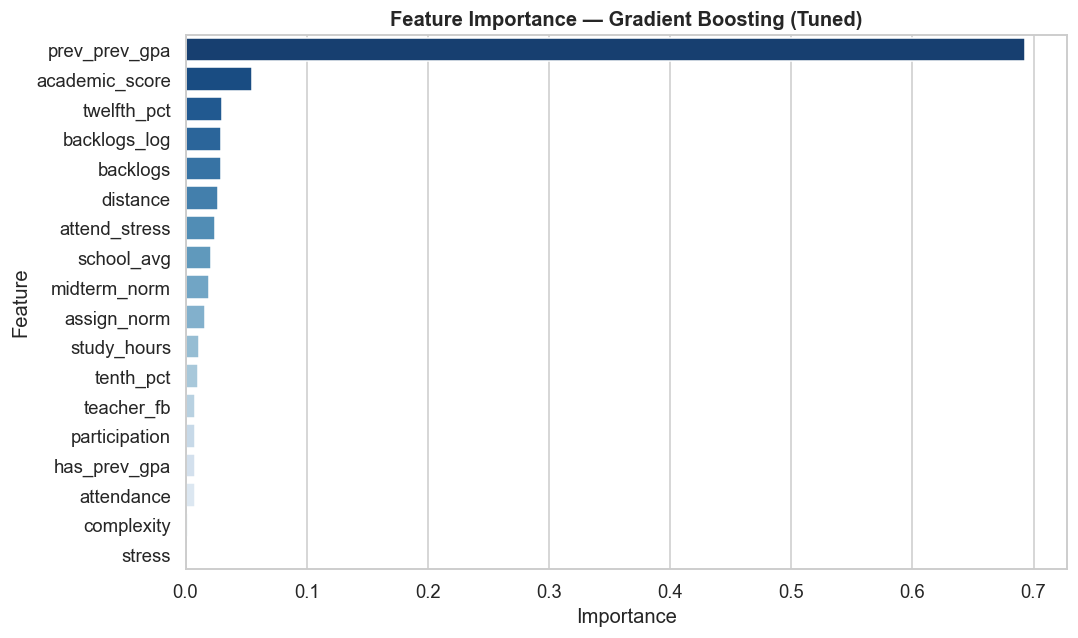

       Feature  Importance
 prev_prev_gpa    0.693286
academic_score    0.055004
   twelfth_pct    0.030449
  backlogs_log    0.029339
      backlogs    0.029296
      distance    0.026656
 attend_stress    0.023940
    school_avg    0.021319
  midterm_norm    0.019217
   assign_norm    0.016010
   study_hours    0.011197
     tenth_pct    0.010451
    teacher_fb    0.008033
 participation    0.007849
  has_prev_gpa    0.007714
    attendance    0.007585
    complexity    0.001876
        stress    0.000778


In [25]:
# Feature importance from Gradient Boosting
try:
    fi = gb_search.best_estimator_.named_steps['m'].feature_importances_
    fi_df = pd.DataFrame({'Feature':FEATURES,'Importance':fi}).sort_values('Importance',ascending=False)
    plt.figure(figsize=(10,6))
    sns.barplot(data=fi_df, y='Feature', x='Importance', palette='Blues_r')
    plt.title('Feature Importance — Gradient Boosting (Tuned)', fontweight='bold')
    plt.tight_layout(); plt.show()
    print(fi_df.to_string(index=False))
except Exception as e:
    print(f'Feature importance unavailable: {e}')

10-Fold Cross-Validation on best model (full dataset)...
10-Fold CV RMSE : 0.6156 ± 0.1142
Per-fold RMSE   : [0.7073 0.85   0.6767 0.5637 0.5464 0.449  0.5534 0.519  0.5642 0.7261]


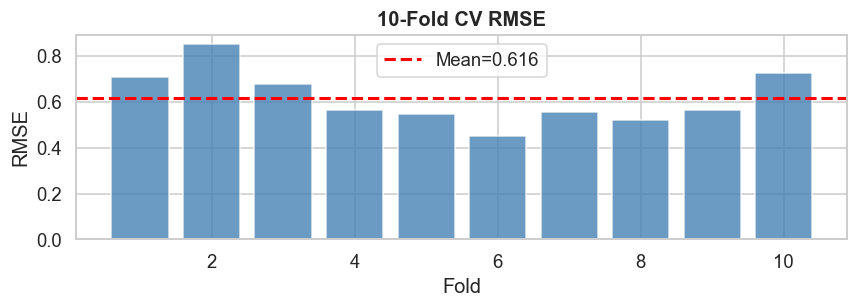

In [26]:
print('10-Fold Cross-Validation on best model (full dataset)...')
cv_scores = cross_val_score(
    best_model, X, y,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error', n_jobs=-1
)
cv_rmse = -cv_scores
print(f'10-Fold CV RMSE : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')
print(f'Per-fold RMSE   : {np.round(cv_rmse, 4)}')

plt.figure(figsize=(8,3))
plt.bar(range(1, 11), cv_rmse, color='steelblue', alpha=0.8)
plt.axhline(cv_rmse.mean(), color='red', lw=2, linestyle='--', label=f'Mean={cv_rmse.mean():.3f}')
plt.xlabel('Fold'); plt.ylabel('RMSE'); plt.title('10-Fold CV RMSE', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

In [29]:
joblib.dump(best_model, 'best_cgpa_model.pkl')
json.dump({'features': FEATURES, 'best_model': best_name}, open('model_meta.json','w'), indent=2)
print('✅ Model saved → best_cgpa_model.pkl')
print('✅ Metadata saved → model_meta.json')

✅ Model saved → best_cgpa_model.pkl
✅ Metadata saved → model_meta.json


## 10. 🔮 Predict New Student CGPA

> Edit the values in `new_student` dict below and run the cell.

In [30]:
import joblib, json, numpy as np, pandas as pd

model_loaded = joblib.load('best_cgpa_model.pkl')
meta         = json.load(open('model_meta.json'))
feat_list    = meta['features']

# ── Fill in student details ────────────────────────────────────────────────
new_student = {
    'midterm_norm' : 40,       # Midterm exam score (raw)
    'assign_norm'  : 17,       # Assignment score average
    'twelfth_pct'  : 80.0,     # 12th grade percentage
    'tenth_pct'    : 85.0,     # 10th grade percentage
    'study_hours'  : 3.0,      # Study hours per day
    'attendance'   : 82.0,     # Attendance percentage
    'backlogs'     : 0,        # Number of backlogs
    'stress'       : 1,        # Mental stress score (0–10)
    'distance'     : 15.0,     # Distance from campus (km)
    'complexity'   : 2,        # 1=Easy, 2=Medium, 3=Hard
    'teacher_fb'   : 3,        # 1=Low, 2=Average, 3=Good
    'participation': 2,        # 1=Less Active … 4=Moderator
    'prev_prev_gpa': np.nan,   # CGPA of the semester before last (or np.nan if unknown)
}

# Auto-derive engineered features
new_student['academic_score']  = (new_student['midterm_norm'] + new_student['assign_norm']) / 2
new_student['school_avg']      = (new_student['twelfth_pct'] + new_student['tenth_pct']) / 2
new_student['backlogs_log']    = np.log1p(new_student['backlogs'])
new_student['attend_stress']   = new_student['attendance'] * (10 - new_student['stress'])
new_student['has_prev_gpa']    = 0 if np.isnan(new_student['prev_prev_gpa']) else 1

inp = pd.DataFrame([{f: new_student.get(f, np.nan) for f in feat_list}])
pred = np.clip(model_loaded.predict(inp)[0], 0, 10)

print('=' * 44)
print('      🎓 CGPA PREDICTION RESULT       ')
print('=' * 44)
print(f'  Predicted CGPA  :  {pred:.2f} / 10.00')
print(f'  Model Used      :  {meta["best_model"]}')
print('=' * 44)

      🎓 CGPA PREDICTION RESULT       
  Predicted CGPA  :  7.49 / 10.00
  Model Used      :  Stacking Ensemble


---
## 📝 Summary

| Item | Detail |
|------|--------|
| Dataset | `original_data.csv` — Real Google Form survey, ~960 submissions |
| Usable rows | ~584 (after cleaning messy target values) |
| Target | `Previous_Semester_GPA` (most complete numeric column) |
| Features | 13 raw survey fields + 5 engineered = **18 total** |
| Cleaning | Regex parsers for GPA, %, hours, km, backlogs, ordinal encodings |
| Models | Ridge, Lasso, EN, KNN, SVR, RF, ET, GB, XGB, LGB, CatBoost, Stacking |
| Tuning | `RandomizedSearchCV` — 60 iters × 5-fold CV per model |
| Key Metrics | **R²** (variance explained), **RMSE** (error magnitude), **±0.5 accuracy** |
| Saved | `best_cgpa_model.pkl`, `model_meta.json` |

> **Why ±0.5 accuracy?**  
> For CGPA prediction, being within 0.5 points (e.g., predicting 7.3 for actual 7.8) is practically acceptable. This metric directly answers: *"How often does our model give a practically useful prediction?"*